# Data Formatting

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib
import statsmodels.api as sm
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import geopandas as gpd
import os
import zipfile

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
from matplotlib import pyplot as plt
from cycler import cycler
from glob import glob


drive.mount('/mnt/drive', force_remount=True)

Mounted at /mnt/drive


In [ ]:
df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()
geo_city_df['GEOID'] = geo_city_df['GEOID'].astype(str)

In [ ]:
sc_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC_ct.csv")
sc_ct['GEOID'] = sc_ct['TRACT'].astype(str).str.zfill(11).str.replace(r"\.0$", "", regex=True)
HD_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_ct.csv")
HD_ct = HD_ct.dropna(subset=['TRACT']).copy()
HD_ct['GEOID'] = HD_ct['TRACT'].astype(int).astype(str).str.zfill(11)
acs_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_ct.csv")
acs_ct['GEOID'] = acs_ct['GEOID'].astype(str).copy()
sc_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC.csv")
sc_zip = sc_zip.dropna(subset=['zip']).copy()
sc_zip['GEOID'] = sc_zip['zip'].astype(int).astype(str).str.zfill(5)
HD_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_zip.csv")
HD_zip['zipCode'] = HD_zip['zipCode'].astype(str).str.strip()
HD_zip['zipCode_clean'] = HD_zip['zipCode'].str.extract(r'(\d+)', expand=False)
HD_zip = HD_zip.dropna(subset=['zipCode_clean']).copy()
HD_zip['GEOID'] = HD_zip['zipCode_clean'].astype(int).astype(str).str.zfill(5)
acs_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_zip.csv")
acs_zip['GEOID'] = acs_zip['GEOID'].astype(int).astype(str).str.zfill(5)

sc_all = pd.concat([sc_ct, sc_zip])
HD_all = pd.concat([HD_ct, HD_zip]).iloc[:, 1:10]
acs_all = pd.concat([acs_ct, acs_zip])

In [ ]:
df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

# Get record from FEMA API
url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$format=csv&$allrecords=true"

# Make it to dataframe
dec = pd.read_csv(url)

# Make FIPS code
dec['fipsStateCode'] = dec['fipsStateCode'].astype(str).str.zfill(2)
dec['fipsCountyCode'] = dec['fipsCountyCode'].astype(str).str.zfill(3)
dec['FIPS'] = dec['fipsStateCode'] + dec['fipsCountyCode']
dec['FIPS'] = dec['FIPS'].astype(str).copy()

# Get a simpler dec
dec = dec[['disasterNumber', 'state', 'designatedArea', 'fipsStateCode', 'fipsCountyCode', 'FIPS']].copy()
dec = pd.merge(dec, df_dis, left_on='disasterNumber', right_on='Num', how='left').copy()
dec = dec.dropna(subset=["month_num"]).copy()

In [ ]:
df_fil_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all.csv").T.iloc[1:]
df_fil_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_zip.csv").T.iloc[1:]
df_combined = pd.concat([df_fil_ct, df_fil_zip])

df_combined = df_combined.reset_index()
df_combined = df_combined.rename(columns={'index': 'disaster_GEOID'})
df_combined[['disasterNumber', 'GEOID']] = df_combined['disaster_GEOID'].str.split('_', expand=True)

df_combined['disasterNumber'] = df_combined['disasterNumber'].astype(str)
df_combined['GEOID'] = df_combined['GEOID'].astype(str)
df_combined = df_combined.drop(columns=['disaster_GEOID'])

# GEOID
df_combined['GEOID'] = df_combined['GEOID'].astype(str)
geo_city_df['GEOID'] = geo_city_df['GEOID'].astype(str)

# Merge
df_combined_with_city = df_combined.merge(
    geo_city_df,
    on='GEOID',
    how='left'
)

cum_df_12 = df_combined
cum_df_12["GEOID"] = cum_df_12["GEOID"].astype(str)

In [ ]:
# --- Create average filings dictionary ---
avg_dict = df_1.groupby("GEOID")["filings_2020_p2"].mean().to_dict()

# --- Merge all necessary data ---
merged_df = cum_df_12.merge(sc_all, on="GEOID", how="left") \
                     .merge(HD_all, on="GEOID", how="left") \
                     .merge(acs_all, on="GEOID", how="left") \
                     .merge(geo_city_df, on="GEOID", how="left")

merged_df = merged_df.rename(columns={"disaster_id": "disaster", "Cumulative_ATT": "cum_att"})

# Disaster Map

In [ ]:
!pip install geopandas shapely pyproj adjustText

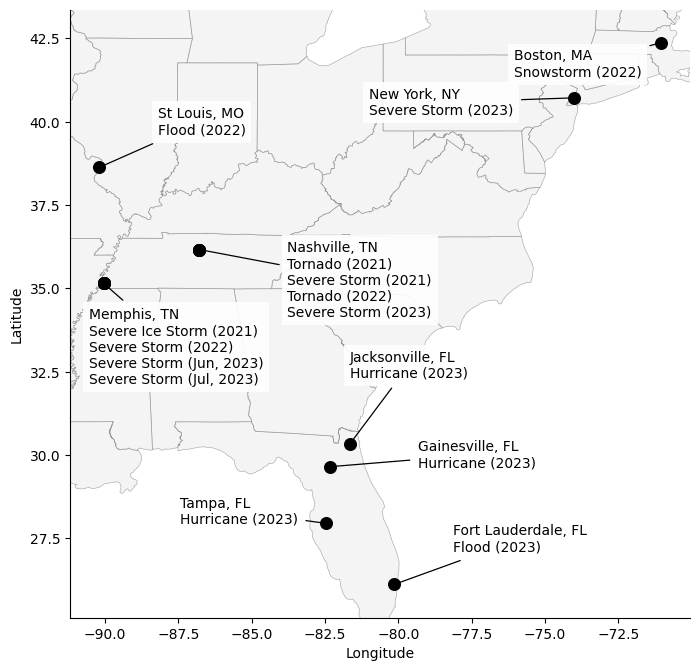

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from adjustText import adjust_text
# --- disaster × city ---
df_combined_with_city['disaster'] = df_combined_with_city['disasterNumber'].astype(str)

df_disaster_city = (
    df_combined_with_city
    .dropna(subset=["city", "disaster"])
    .drop_duplicates(subset=["city", "disaster"])
)

city_coords = {
    "New York, NY": (40.7128, -74.0060),
    "Boston, MA": (42.3601, -71.0589),
    "Fort Lauderdale, FL": (26.1224, -80.1373),
    "Gainesville, FL": (29.6516, -82.3248),
    "Jacksonville, FL": (30.3322, -81.6557),
    "Memphis, TN": (35.1495, -90.0490),
    "Nashville, TN": (36.1627, -86.7816),
    "St Louis, MO": (38.6270, -90.1994),
    "Tampa, FL": (27.9506, -82.4572),
}

# city lat lon
df_disaster_city["lat"] = df_disaster_city["city"].map(
    lambda c: city_coords.get(c, (np.nan, np.nan))[0]
)
df_disaster_city["lon"] = df_disaster_city["city"].map(
    lambda c: city_coords.get(c, (np.nan, np.nan))[1]
)

df_disaster_city = df_disaster_city.dropna(subset=["lat", "lon"])

disaster_type_dict = {
    "4755": "Severe Storm (2023)",
    "4735": "Severe Storm (Jul, 2023)",
    "4729": "Severe Storm (Jun, 2023)",
    "4665": "Flood (2022)",
    "4651": "Snowstorm (2022)",
    "4645": "Severe Storm (2022)",
    "4637": "Tornado (2022)",
    "4601": "Tornado (2021)",
    "4594": "Severe Ice Storm (2021)",
    "4751": "Severe Storm (2021)",
    "4734": "Hurricane (2023)",
    "4712": "Severe Storm (2023)",
    "4709": "Flood (2023)",
    "4644": "Severe Storm (2022)",
    "4602": "Severe Ice Storm (2021)"
}

states = gpd.read_file("/mnt/drive/MyDrive/Colab_data/tl_2022_us_state/tl_2022_us_state.shp")

fig, ax = plt.subplots(figsize=(8, 8))

states.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="gray",
    linewidth=0.5,
    alpha=0.6
)

df_disaster_city["disaster_label"] = (
    df_disaster_city["disaster"]
    .map(disaster_type_dict)
    .fillna(df_disaster_city["disaster"])
)

city_disaster_list = (
    df_disaster_city
    .assign(
        year=lambda d: d["disaster_label"].str.extract(r"\((\d{4})\)").astype(float)
    )
    .sort_values("year")
    .groupby("city")["disaster_label"]
    .apply(list)
    .to_dict()
)


manual_city_label_offsets = {
    "Boston, MA": (-5, -1),
    "Memphis, TN": (-0.5, -3),
    "Tampa, FL": (-5, 0),
    "Jacksonville, FL": (0, 2),
    "Gainesville, FL": (3, 0),
    "Nashville, TN": (3, -2),
    "New York, NY": (-7, -0.5),
}

city_centers = (
    df_disaster_city
    .groupby("city")[["lon", "lat"]]
    .mean()
    .reset_index()
)

ax.set_xlim(
    city_centers["lon"].min() - 1,
    city_centers["lon"].max() + 1
)
ax.set_ylim(
    city_centers["lat"].min() - 1,
    city_centers["lat"].max() + 1
)

# --- disaster point ---
for _, r in df_disaster_city.iterrows():
    ax.scatter(
        r["lon"],
        r["lat"],
        s=70,
        color="black",
        edgecolor="k",
        zorder=3
    )

# --- city label ---
for _, r in city_centers.iterrows():

    city = r["city"]
    x, y = r["lon"], r["lat"]

    disasters = city_disaster_list.get(city, [])
    disaster_txt = "\n".join(disasters)

    dx, dy = manual_city_label_offsets.get(city, (2.0, 1.0))

    label = f"{city}\n{disaster_txt}"

    ax.annotate(
        label,
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="none"),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.9
        ),
        zorder=4
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig("figure.png", dpi=200)
plt.show()
from google.colab import files
files.download("figure.png")


# Map Tre-Control

In [ ]:
import os
from glob import glob
import pandas as pd
import geopandas as gpd

base_dir = "/mnt/drive/MyDrive/Colab_data"

# -------------------------------
# 1. 2022 tract
# -------------------------------
shapefiles_2022 = glob(os.path.join(base_dir, "tl_2022_*_tract.shp"))
gdfs_2022 = [gpd.read_file(shp) for shp in shapefiles_2022]

tracts_2022 = gpd.GeoDataFrame(
    pd.concat(gdfs_2022, ignore_index=True),
    crs=gdfs_2022[0].crs
)

# -------------------------------
# 2. 2021 tract
# -------------------------------
shapefiles_2021 = glob(os.path.join(base_dir, "tl_2021_*_tract.shp"))
gdfs_2021 = [gpd.read_file(shp) for shp in shapefiles_2021]

tracts_2021 = gpd.GeoDataFrame(
    pd.concat(gdfs_2021, ignore_index=True),
    crs=gdfs_2021[0].crs
)

# -------------------------------
# 3. Difference
# -------------------------------
states_2022 = set(tracts_2022["STATEFP"].unique())
states_2021 = set(tracts_2021["STATEFP"].unique())

missing_states = states_2021 - states_2022

print("Missing states (filled from 2021):", sorted(missing_states))

# -------------------------------
# 4. Merge
# -------------------------------
tracts_2021_missing = tracts_2021[
    tracts_2021["STATEFP"].isin(missing_states)
]

# -------------------------------
# 5. Combined
# -------------------------------
tracts_all = gpd.GeoDataFrame(
    pd.concat([tracts_2022, tracts_2021_missing], ignore_index=True),
    crs=tracts_2022.crs
)

# -------------------------------
# 6. Web Mercator
# -------------------------------
tracts_all = tracts_all.to_crs(epsg=3857)


Missing states (filled from 2021): ['29']


In [ ]:
tracts_all["GEOID"] = tracts_all["GEOID"].astype(str)
df_1["GEOID"] = df_1["GEOID"].astype(str)

target_tracts = tracts_all[tracts_all["GEOID"].isin(df_1["GEOID"])]

In [ ]:
import geopandas as gpd
import pandas as pd
from glob import glob
import os

base_dir = "/mnt/drive/MyDrive/Colab_data/tl_2020_us_zcta520"
shapefiles = glob(os.path.join(base_dir, "tl_2020_us_zcta520.shp"))
gdfs = [gpd.read_file(shp) for shp in shapefiles]
zip_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)
zip_all = zip_all.to_crs(epsg=3857)

In [ ]:
zip_all["GEOID"] = zip_all["GEOID20"].astype(str)
df_2["GEOID"] = df_2["GEOID"].astype(str)
df_2["FIPS"] = df_2["FIPS"].astype(str).str[:5]

target_zip = zip_all[zip_all["GEOID"].isin(df_2["GEOID"])]

In [ ]:
import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

dec["disasterNumber"] = dec["disasterNumber"].astype(str)
df_1["GEOID"] = df_1["GEOID"].astype(str)  # Tract
df_2["GEOID"] = df_2["GEOID"].astype(str)  # ZIP
df_2["FIPS"] = df_2["FIPS"].astype(str)
tracts_all["GEOID"] = tracts_all["GEOID"].astype(str)
zip_all["GEOID"] = zip_all["GEOID"].astype(str)
geo_city_df["GEOID"] = geo_city_df["GEOID"].astype(str)


In [ ]:
disaster_list = sorted(dec["disasterNumber"].dropna().unique())
valid_disasters = []

for disaster_id in disaster_list:
    print(disaster_id)
    fips = dec.loc[dec["disasterNumber"] == disaster_id, "FIPS"].astype(str).unique()
    if len(fips) == 0 or fips[0][:2] == "51":  # No VA
        continue

    # --- Tract ---
    treated_tracts_geoids = df_1.loc[df_1["FIPS"].astype(str).isin(fips), "GEOID"].astype(str).unique()
    print(treated_tracts_geoids)
    state_codes_unique = list(set([geoid[:2] for geoid in treated_tracts_geoids]))
    if state_codes_unique:
        control_tracts_geoids = df_1.loc[
            df_1["GEOID"].astype(str).str[:2].isin(state_codes_unique) & (~df_1["GEOID"].astype(str).isin(treated_tracts_geoids)),
            "GEOID"
        ].astype(str).unique()
    else:
        control_tracts_geoids = []
    print(control_tracts_geoids)

    if len(treated_tracts_geoids) > 0 and len(control_tracts_geoids) > 0:
        valid_disasters.append((disaster_id, "tract"))
        continue

    # --- ZIP ---
    treated_zips_geoids = df_2.loc[df_2["FIPS"].astype(str).isin(fips), "GEOID"].astype(str).unique()
    print(treated_zips_geoids)
    state_codes_unique = list(set([geoid[:2] for geoid in treated_zips_geoids]))
    if state_codes_unique:
        control_zips_geoids = df_2.loc[
            df_2["GEOID"].astype(str).str[:2].isin(state_codes_unique) & (~df_2["GEOID"].astype(str).isin(treated_zips_geoids)),
            "GEOID"
        ].astype(str).unique()
    else:
        control_zips_geoids = []

    print(control_zips_geoids)

    if len(treated_zips_geoids) > 0 and len(control_zips_geoids) > 0:
        valid_disasters.append((disaster_id, "zip"))

4586
['48113000100' '48113000201' '48113000202' ... '48201980100' '48201980200'
 '48201980700']
[]
['76574' '78610' '78612' '78613' '78615' '78616' '78617' '78620' '78621'
 '78634' '78640' '78641' '78642' '78645' '78652' '78653' '78654' '78660'
 '78663' '78664' '78669' '78701' '78702' '78703' '78704' '78705' '78712'
 '78719' '78721' '78722' '78723' '78724' '78725' '78726' '78727' '78728'
 '78729' '78730' '78731' '78732' '78733' '78734' '78735' '78736' '78737'
 '78738' '78739' '78741' '78742' '78744' '78745' '78746' '78747' '78748'
 '78749' '78750' '78751' '78752' '78753' '78754' '78756' '78757' '78758'
 '78759']
[]
4587
[]
[]
[]
[]
4589
[]
[]
[]
[]
4590
['22071000100' '22071000200' '22071000300' '22071000400' '22071000601'
 '22071000602' '22071000603' '22071000604' '22071000605' '22071000606'
 '22071000607' '22071000611' '22071000612' '22071000615' '22071000616'
 '22071000617' '22071000618' '22071000619' '22071000620' '22071000701'
 '22071000702' '22071000800' '22071000901' '2207100090

In [ ]:
valid_disasters

[('4594', 'tract'),
 ('4601', 'tract'),
 ('4637', 'tract'),
 ('4645', 'tract'),
 ('4651', 'tract'),
 ('4665', 'tract'),
 ('4709', 'tract'),
 ('4712', 'tract'),
 ('4729', 'tract'),
 ('4734', 'tract'),
 ('4735', 'tract'),
 ('4751', 'tract'),
 ('4755', 'zip')]

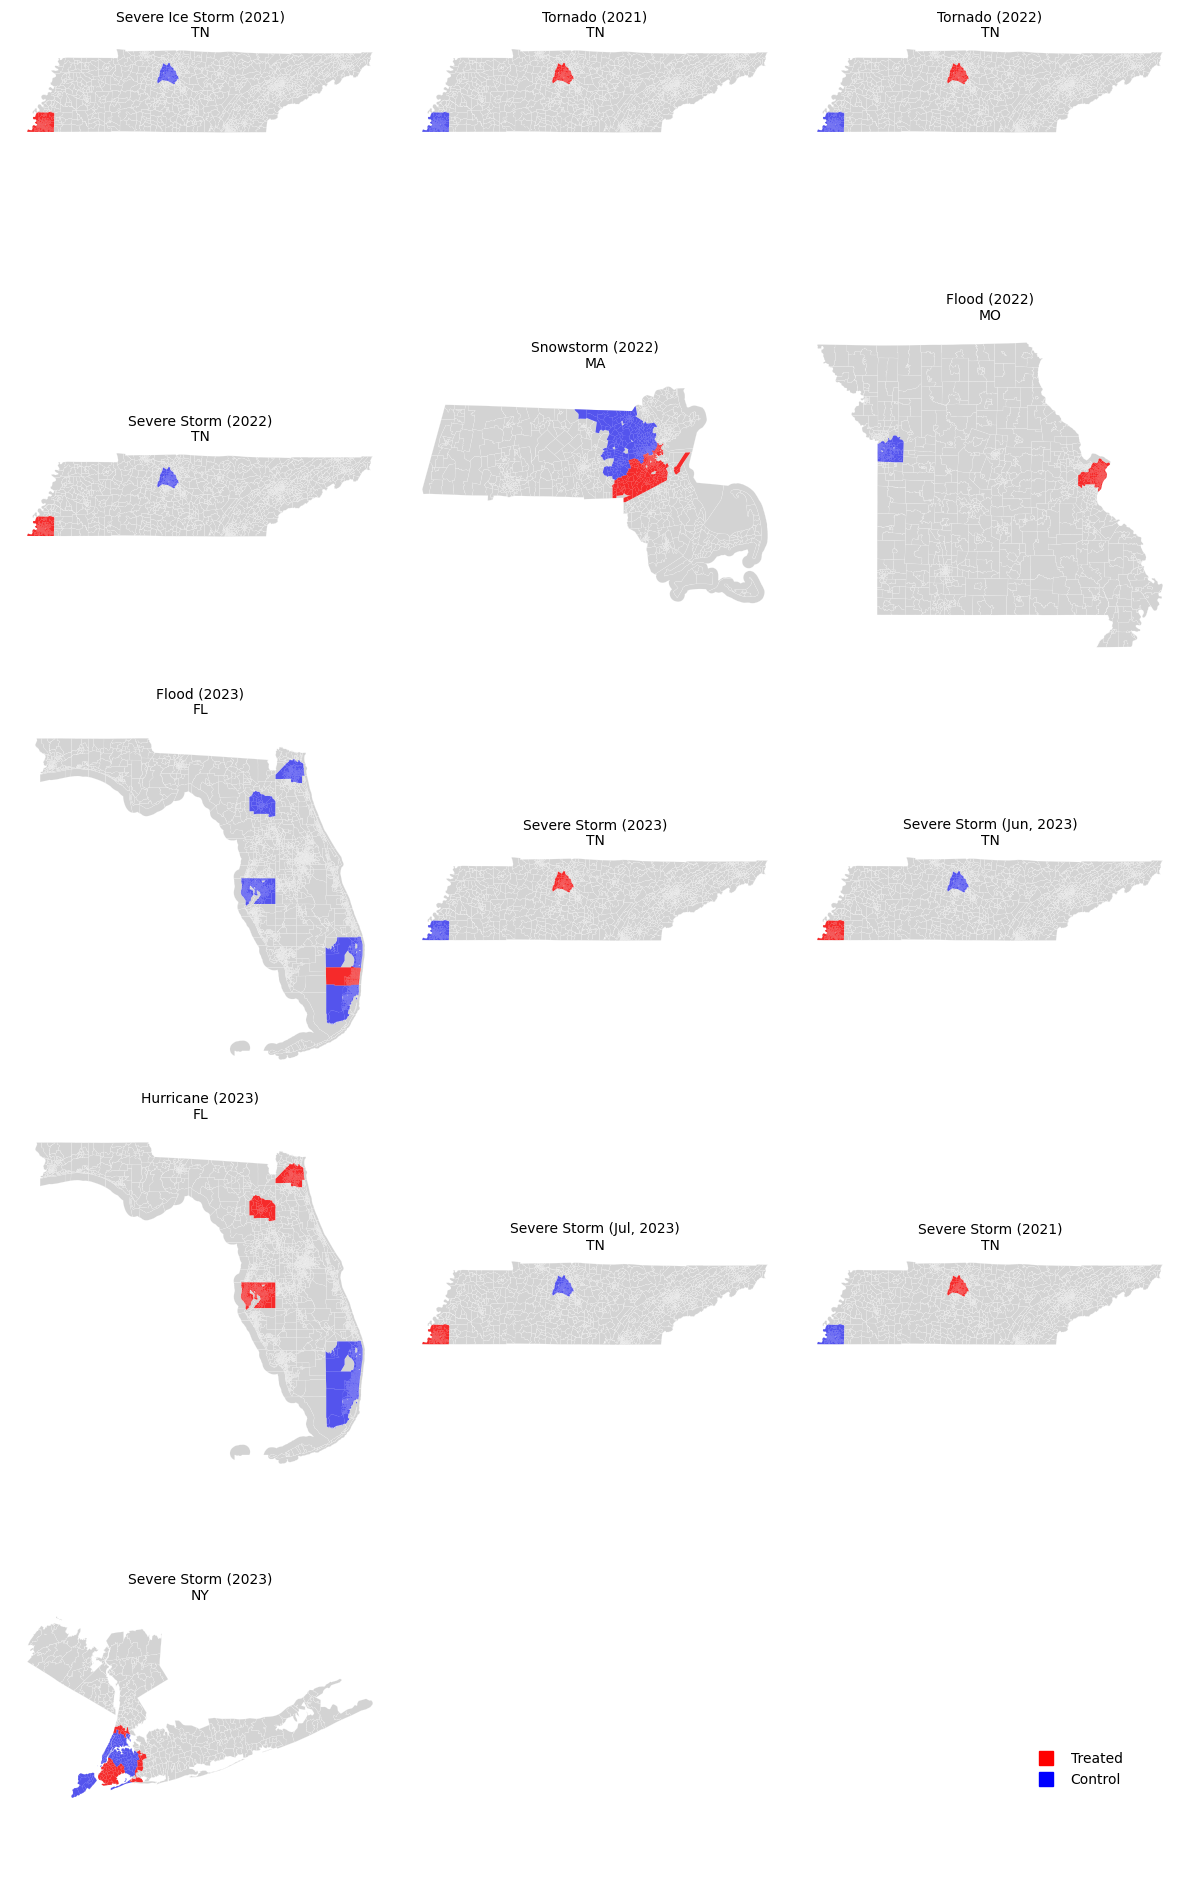

In [ ]:
# Sort disasters by disasterNumber
valid_disasters_sorted = sorted(valid_disasters, key=lambda x: x[0])

n = len(valid_disasters_sorted)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows))
axes = axes.flatten()

for i, (disaster_id, dtype) in enumerate(valid_disasters_sorted):
    ax = axes[i]

    fips = dec.loc[dec["disasterNumber"] == disaster_id, "FIPS"].astype(str).unique()
    if len(fips) == 0:
        continue

    if dtype == "tract":
        # --- Treated and control tracts ---
        treated_geoids = df_1.loc[df_1["GEOID"].str[:5].isin(fips), "GEOID"].unique()
        state_code_tract = treated_geoids[0][:2] if len(treated_geoids) > 0 else None
        control_geoids = df_1.loc[
            (df_1["GEOID"].str[:2] == state_code_tract) & (~df_1["GEOID"].isin(treated_geoids)),
            "GEOID"
        ].unique() if state_code_tract else []

        treated_gdf = tracts_all[tracts_all["GEOID"].isin(treated_geoids)]
        control_gdf = tracts_all[tracts_all["GEOID"].isin(control_geoids)]
        state_gdf = tracts_all[tracts_all["GEOID"].str[:2] == state_code_tract]

    else:  # ZIP
        # --- Treated and control ZIPs ---
        treated_geoids = df_2.loc[df_2["FIPS"].astype(str).isin(fips), "GEOID"].astype(str).unique()
        state_codes_unique = list(set([geoid[:2] for geoid in treated_geoids]))
        control_geoids = df_2.loc[
            df_2["GEOID"].astype(str).str[:2].isin(state_codes_unique) & (~df_2["GEOID"].isin(treated_geoids)),
            "GEOID"
        ].astype(str).unique() if state_codes_unique else []

        treated_gdf = zip_all[zip_all["GEOID"].isin(treated_geoids)]
        control_gdf = zip_all[zip_all["GEOID"].isin(control_geoids)]
        state_gdf = zip_all[zip_all["GEOID"].str[:2].isin(state_codes_unique)]

    # --- Plot ---
    state_gdf.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.1)
    if len(control_gdf) > 0:
        control_gdf.plot(ax=ax, color="blue", alpha=0.6)
    if len(treated_gdf) > 0:
        treated_gdf.plot(ax=ax, color="red", alpha=0.8)

    # --- Title ---
    disaster_name = disaster_type_dict.get(disaster_id, f"Disaster {disaster_id}")
    cities = geo_city_df.loc[geo_city_df["GEOID"].isin(treated_geoids), "city"]
    city_name = cities.mode().iloc[0][-2:] if len(cities) > 0 else "Unknown City"
    ax.set_title(f"{disaster_name}\n{city_name}", fontsize=10)
    ax.axis("off")

for ax in axes[len(valid_disasters_sorted):]:
    ax.axis("off")

# --- Ledgend ---
treated_handle = mlines.Line2D([], [], color="red", marker="s",
                               linestyle="None", markersize=10, label="Treated")
control_handle = mlines.Line2D([], [], color="blue", marker="s",
                               linestyle="None", markersize=10, label="Control")

fig.legend(
    handles=[treated_handle, control_handle],
    loc="lower right",
    bbox_to_anchor=(0.95, 0.05),
    frameon=False,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("figure.png", dpi=200)
plt.show()


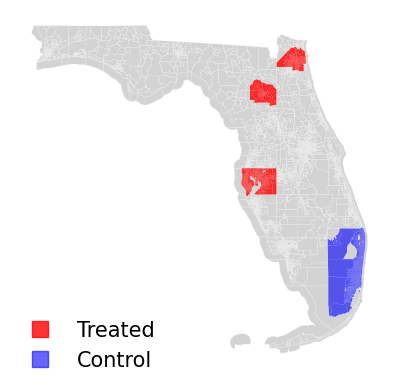

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

valid_disasters_sorted = ["4734"]

# -------------------------------
# Subplot
# -------------------------------
n = len(valid_disasters_sorted)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
axes = [axes] if n == 1 else axes

# -------------------------------
# Plot per disaster
# -------------------------------
for i, disaster_id in enumerate(valid_disasters_sorted):
    ax = axes[i]

    fips = dec.loc[
        dec["disasterNumber"].astype(str) == disaster_id, "FIPS"
    ].astype(str).unique()

    if len(fips) == 0:
        continue

    treated_geoids = df_1.loc[
        df_1["GEOID"].astype(str).str[:5].isin(fips),
        "GEOID"
    ].astype(str).unique()

    if len(treated_geoids) == 0:
        continue

    state_code = str(fips[0])[:2]
    df_1["state"] = df_1["state"].astype(str)
    df_state = df_1[df_1["state"] == state_code].copy()

    control_geoids = df_state.loc[
        ~df_state["GEOID"].isin(treated_geoids), "GEOID"
        ].unique()

    treated_gdf = tracts_all[tracts_all["GEOID"].isin(treated_geoids)]
    control_gdf = tracts_all[tracts_all["GEOID"].isin(control_geoids)]
    state_gdf = tracts_all[tracts_all["GEOID"].str[:2] == state_code]

    state_gdf.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.1)
    control_gdf.plot(ax=ax, color="blue", alpha=0.6)
    treated_gdf.plot(ax=ax, color="red", alpha=0.8)

    disaster_name = disaster_type_dict.get(disaster_id, f"Disaster {disaster_id}")
    # ax.set_title(disaster_name)
    ax.axis("off")

# -------------------------------
# Legend
# -------------------------------
treated_handle = mlines.Line2D([], [], color="red", marker="s",
                               linestyle="None", markersize=12, label="Treated", alpha=0.8)
control_handle = mlines.Line2D([], [], color="blue", marker="s",
                               linestyle="None", markersize=12, label="Control", alpha=0.6)

fig.legend(
    handles=[treated_handle, control_handle],
    loc="lower left",
    frameon=False,
    fontsize=15
)

plt.tight_layout()
plt.savefig("figure.png", dpi=200)
plt.show()
from google.colab import files
files.download("figure.png")


# Time seriese

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [ ]:
df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()

df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

In [ ]:
df_1 = df_1[np.isfinite(df_1['filings_2020_p2'])]
df_2 = df_2[np.isfinite(df_2['filings_2020_p2'])]

In [ ]:
# Get record from FEMA API
url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$format=csv&$allrecords=true"

# Make it to dataframe
dec = pd.read_csv(url)

# Make FIPS code
dec['fipsStateCode'] = dec['fipsStateCode'].astype(str).str.zfill(2)
dec['fipsCountyCode'] = dec['fipsCountyCode'].astype(str).str.zfill(3)
dec['FIPS'] = dec['fipsStateCode'] + dec['fipsCountyCode']
dec['FIPS'] = dec['FIPS'].astype(str).copy()

# Get a simpler dec
dec = dec[['disasterNumber', 'state', 'designatedArea', 'fipsStateCode', 'fipsCountyCode', 'FIPS']].copy()
dec = pd.merge(dec, df_dis, left_on='disasterNumber', right_on='Num', how='left').copy()
dec = dec.dropna(subset=["month_num"]).copy()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [ ]:
# -----------------------------------
# Synthetic Control Class
# -----------------------------------
class SyntheticControl(BaseEstimator, RegressorMixin):
    def __init__(self):
        pass

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
        w = cp.Variable(y_pre_co.shape[1])
        objective = cp.Minimize(cp.sum_squares(y_pre_co @ w - y_pre_tr))
        constraints = [cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(objective, constraints)
        self.loss_ = prob.solve(verbose=False)
        self.w_ = w.value
        self.is_fitted_ = True
        return self

    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(y_co)
        return y_co @ self.w_

# -----------------------------------
# reshape function
# -----------------------------------
def reshape_sc_data(df, geo_col, time_col, y_col, tr_geos, tr_start):
    df_piv = df.pivot_table(values=y_col, index=time_col, columns=geo_col)
    y_co = df_piv.drop(columns=tr_geos)
    y_tr = df_piv[tr_geos]
    y_pre_co = y_co[df_piv.index < tr_start]
    y_pre_tr = y_tr[df_piv.index < tr_start]
    y_post_co = y_co[df_piv.index >= tr_start]
    y_post_tr = y_tr[df_piv.index >= tr_start]
    return y_pre_co, y_pre_tr, y_post_co, y_post_tr


=== Processing Disaster 4734 ===
1468
--- GEOID 12001000201 completed ---
--- GEOID 12001000202 completed ---
--- GEOID 12001000301 completed ---
--- GEOID 12001000302 completed ---
--- GEOID 12001000400 completed ---
--- GEOID 12001000500 completed ---
--- GEOID 12001000600 completed ---
--- GEOID 12001000700 completed ---
--- GEOID 12001000806 completed ---
--- GEOID 12001000808 completed ---
--- GEOID 12001000809 completed ---
--- GEOID 12001000901 completed ---
--- GEOID 12001000902 completed ---
--- GEOID 12001001000 completed ---
--- GEOID 12001001100 completed ---
--- GEOID 12001001201 completed ---
--- GEOID 12001001202 completed ---
--- GEOID 12001001203 completed ---
--- GEOID 12001001400 completed ---
--- GEOID 12001001514 completed ---
--- GEOID 12001001515 completed ---
--- GEOID 12001001516 completed ---
--- GEOID 12001001517 completed ---
--- GEOID 12001001519 completed ---
--- GEOID 12001001522 completed ---
--- GEOID 12001001605 completed ---
--- GEOID 12001001701 com

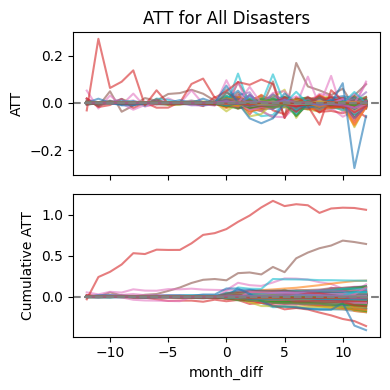

In [ ]:
disaster_list = ["4734"]
df_1['state'] = df_1['state'].astype(str)

# Dictionary
att_all = {}
cum_att_all = {}

for disaster_id in disaster_list:
    print(f"\n=== Processing Disaster {disaster_id} ===")

    # --- FIPS & Treatment GEOIDs ---
    impact_month = int(
        dec.loc[
            dec["disasterNumber"].astype(str) == disaster_id,
            "month_num"
        ].iloc[0]
    )

    fips = dec.loc[
        dec["disasterNumber"].astype(str) == disaster_id, "FIPS"
    ].unique()

    treat_geoids = df_1.loc[
        df_1["GEOID"].astype(str).str[:5].isin(fips), "GEOID"
    ].unique()

    state_code = str(fips[0])[:2]
    df_1["state"] = df_1["state"].astype(str)
    df_state = df_1[df_1["state"] == state_code].copy()

    control_geoids = df_state.loc[
        ~df_state["GEOID"].isin(treat_geoids), "GEOID"
    ].unique()
    print(len(control_geoids))
   # Skip if there are no controls
    if len(control_geoids) == 0:
        print(f"No control GEOIDs available for disaster {disaster_id}, skipping...")
        continue

    # --- month_diff ---
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # --- Only complete GEOIDs---
    all_months = set(range(-12, 13))
    valid_geoids = [geo for geo in list(treat_geoids) + list(control_geoids)
                    if all_months.issubset(set(df_trim.loc[df_trim["GEOID"] == geo, "month_diff"]))]

    # --- Synthetic Control ---
    for geo in treat_geoids:
        if geo not in valid_geoids:
            print(f"Treatment GEOID {geo} does not have full months, skip")
            continue

        df_tr = df_trim[df_trim["GEOID"] == geo].copy()
        df_co = df_trim[df_trim["GEOID"].isin(valid_geoids) & df_trim["GEOID"].isin(control_geoids)].copy()

        df_sc = pd.concat([df_tr, df_co])

        y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
            df_sc, geo_col="GEOID", time_col="month_diff", y_col="filings_2020_p2",
            tr_geos=[geo], tr_start=0
        )

        model = SyntheticControl()
        model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)

        y_co = pd.concat([y_pre_co, y_post_co])
        y_tr = pd.concat([y_pre_tr, y_post_tr])
        y_hat = model.predict(y_co.values)

        # --- Save ---
        key = f"{disaster_id}_{geo}"
        att_all[key] = y_tr.mean(axis=1) - y_hat
        cum_att_all[key] = att_all[key].cumsum()

        print(f"--- GEOID {geo} completed ---")

# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(4, 4), sharex=True)

for key in att_all:
    axs[0].plot(att_all[key].index, att_all[key], alpha=0.6, label=key)
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters")

for key in cum_att_all:
    axs[1].plot(cum_att_all[key].index, cum_att_all[key], alpha=0.6, label=key)
axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

plt.tight_layout()
plt.show()


-0.0002353000301071145 0.000141179842657167


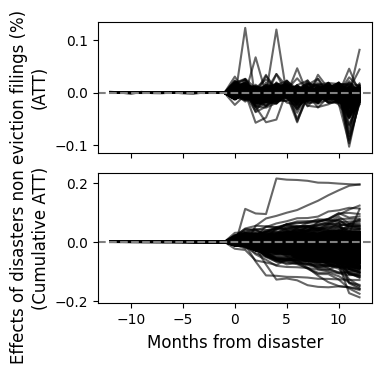

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Filtering ---
baseline = pd.DataFrame(cum_att_all).T
baseline_pre = baseline.loc[:, baseline.columns == -1]
baseline_pre = baseline_pre.squeeze()

Q1 = baseline_pre.quantile(0.25)
Q3 = baseline_pre.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

# --- valid GEOID ---
valid_geoids = baseline_pre[(baseline_pre >= lower) & (baseline_pre <= upper)].index.tolist()

# --- Filter dict ---
att_all_filtered = {k: v for k, v in att_all.items() if k in valid_geoids}
cum_att_all_filtered = {k: v for k, v in cum_att_all.items() if k in valid_geoids}

# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(4, 4), sharex=True)

# ATT
for key in att_all_filtered:
    axs[0].plot(att_all_filtered[key].index, att_all_filtered[key], alpha=0.6, color="black")
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("(ATT)", fontsize=12)

# Cumulative ATT
for key in cum_att_all_filtered:
    axs[1].plot(cum_att_all_filtered[key].index, cum_att_all_filtered[key], alpha=0.6, color="black")

axs[1].axhline(0, color="gray", linestyle="--")

axs[1].set_ylabel("(Cumulative ATT)", fontsize=12, labelpad=3.5)
axs[1].set_xlabel("Months from disaster", fontsize=12, labelpad=5)

fig.text(0.08, 0.5,
         "Effects of disasters non eviction filings (%)",
         va='center', ha='center', rotation='vertical', fontsize=12)


plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.savefig("figure.png", dpi=200)
plt.show()
from google.colab import files
files.download("figure.png")